# 0. Import Library

In [90]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import KFold

# 1. Load Dataset & Split Dataset

## 1.1 Load Dataset

In [91]:
# Load data
df = pd.read_csv("stock_prices.csv")

# Kolom yang akan dipertahankan
keep_cols = ["RowId", "Date", "SecuritiesCode", "Open", "High", "Low", "Close", "Volume", "Target"]
df = df[keep_cols].copy()

# Format kolom "Date" menjadi tipe datetime
df["Date"] = pd.to_datetime(df["Date"])

# Memastikan urutan data berdasarkan tanggal
df = df.sort_values("Date").reset_index(drop=True)

print(f"Total rows: {len(df)}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")

Total rows: 2332531
Date range: 2017-01-04 → 2021-12-03


## 1.2 Timeseries Split

In [92]:
# Split berdasarkan tanggal, 80% untuk train dan 20% untuk test
split_date = df["Date"].quantile(0.8)  

train = df[df["Date"] <= split_date].copy()
test  = df[df["Date"] >  split_date].copy()

print(f"\nTrain: {train['Date'].min().date()} → {train['Date'].max().date()}  ({len(train)} rows)")
print(f"Test : {test['Date'].min().date()} → {test['Date'].max().date()}  ({len(test)} rows)")

train.to_csv("train.csv", index=True)
test.to_csv("test.csv", index=True)


Train: 2017-01-04 → 2020-12-21  (1866532 rows)
Test : 2020-12-22 → 2021-12-03  (465999 rows)


# 2. Missing Values

## 2.1 Load Dataset After Split

In [93]:
# Load train and test data 
BASE_DIR = Path.cwd()
train = pd.read_csv(BASE_DIR / "train.csv")
test  = pd.read_csv(BASE_DIR / "test.csv")

# Re-parse kolom "Date"
train["Date"] = pd.to_datetime(train["Date"])
test["Date"]  = pd.to_datetime(test["Date"])

print(f"\ntrain: {train.shape}")
print(f"test : {test.shape}")
train.head()


train: (1866532, 10)
test : (465999, 10)


,Unnamed: 0,RowId,Date,SecuritiesCode,Open,High,Low,Close,Volume,Target
0,0,20170104_1301,2017-01-04,1301,2734.0,2755.0,2730.0,2742.0,31400,0.000730
1,1,20170104_7412,2017-01-04,7412,719.0,725.0,719.0,721.0,201400,0.000000
2,2,20170104_7408,2017-01-04,7408,2459.0,2518.0,2447.0,2500.0,110900,0.004421
3,3,20170104_7315,2017-01-04,7315,465.0,494.0,465.0,493.0,41100,-0.004032
4,4,20170104_7313,2017-01-04,7313,3055.0,3150.0,3045.0,3135.0,248600,-0.009693


## 2.2 Dataset Shape & Dtypes

In [94]:
print(f"Shape: {train.shape}")
print("\nDtypes:")
print(train.dtypes)

Shape: (1866532, 10)

Dtypes:
Unnamed: 0                 int64
RowId                        str
Date              datetime64[us]
SecuritiesCode             int64
Open                     float64
High                     float64
Low                      float64
Close                    float64
Volume                     int64
Target                   float64
dtype: object


## 2.3 Missing Values in Train & Test

In [95]:
missing = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_pct":   (train.isna().mean() * 100).round(4),
    "dtype":         train.dtypes.astype(str),
}).sort_values("missing_count", ascending=False)
print(missing)

                missing_count  missing_pct           dtype
Open                     6503       0.3484         float64
High                     6503       0.3484         float64
Close                    6503       0.3484         float64
Low                      6503       0.3484         float64
Target                    238       0.0128         float64
Unnamed: 0                  0       0.0000           int64
RowId                       0       0.0000             str
SecuritiesCode              0       0.0000           int64
Date                        0       0.0000  datetime64[us]
Volume                      0       0.0000           int64


In [96]:
missing_test = pd.DataFrame({
    "missing_count": test.isna().sum(),
    "missing_pct":   (test.isna().mean() * 100).round(4),
}).sort_values("missing_count", ascending=False)
print(missing_test)

                missing_count  missing_pct
Open                     1105       0.2371
High                     1105       0.2371
Close                    1105       0.2371
Low                      1105       0.2371
RowId                       0       0.0000
Unnamed: 0                  0       0.0000
Date                        0       0.0000
SecuritiesCode              0       0.0000
Volume                      0       0.0000
Target                      0       0.0000


## 2.4 Missing Values in Train

In [97]:
# ============================================================
# 2.4 Missing Values in Train
# ============================================================

total_cells           = train.shape[0] * train.shape[1]
total_missing         = train.isna().sum().sum()
rows_with_any_missing = train.isna().any(axis=1).sum()
rows_with_all_missing = train.isna().all(axis=1).sum()

print(f"Total cells           : {total_cells}")
print(f"Total missing cells   : {total_missing}  ({total_missing / total_cells * 100:.4f}%)")
print(f"Rows w/ >=1 missing   : {rows_with_any_missing}  ({rows_with_any_missing / len(train) * 100:.4f}%)")
print(f"Rows w/ ALL missing   : {rows_with_all_missing}")

for col in train.columns:
    if train[col].isna().any():
        idx = train.index[train[col].isna()]
        print(f"{col:16s} | first @row {idx.min():>7} | last @row {idx.max():>7} | n_missing={len(idx)}")
    else:
        print(f"{col:16s} | no missing values")


Total cells           : 18665320
Total missing cells   : 26250  (0.1406%)
Rows w/ >=1 missing   : 6503  (0.3484%)
Rows w/ ALL missing   : 0
Unnamed: 0       | no missing values
RowId            | no missing values
Date             | no missing values
SecuritiesCode   | no missing values
Open             | first @row     664 | last @row 1866281 | n_missing=6503
High             | first @row     664 | last @row 1866281 | n_missing=6503
Low              | first @row     664 | last @row 1866281 | n_missing=6503
Close            | first @row     664 | last @row 1866281 | n_missing=6503
Volume           | no missing values
Target           | first @row    1141 | last @row 1758123 | n_missing=238


## 2.5 Missing Values by Year

In [98]:
train["_year"] = train["Date"].dt.year
print(train.groupby("_year").apply(lambda g: g.isna().sum()))
train.drop(columns="_year", inplace=True)

       Unnamed: 0  RowId  Date  SecuritiesCode  Open  High   Low  Close  \
_year                                                                     
2017            0      0     0               0  1131  1131  1131   1131   
2018            0      0     0               0  1024  1024  1024   1024   
2019            0      0     0               0  1217  1217  1217   1217   
2020            0      0     0               0  3131  3131  3131   3131   

       Volume  Target  
_year                  
2017        0     235  
2018        0       1  
2019        0       0  
2020        0       2  


## 2.6 Missng Values by Security

In [99]:
per_sec = train.groupby("SecuritiesCode").apply(lambda g: g.isna().sum())
per_sec = per_sec[per_sec.sum(axis=1) > 0]
if per_sec.empty:
    print("No security has any missing values.")
else:
    print(f"{per_sec.shape[0]} securities have missing values. Top 10:")
    print(per_sec.assign(total=per_sec.sum(axis=1))
                  .sort_values("total", ascending=False).head(10))

1991 securities have missing values. Top 10:
                Unnamed: 0  RowId  Date  Open  High  Low  Close  Volume  \
SecuritiesCode                                                            
3540                     0      0     0   237   237  237    237       0   
9733                     0      0     0   269   269  269    269       0   
2761                     0      0     0   242   242  242    242       0   
4365                     0      0     0   234   234  234    234       0   
1787                     0      0     0   233   233  233    233       0   
4628                     0      0     0   217   217  217    217       0   
1981                     0      0     0   217   217  217    217       0   
4781                     0      0     0   210   210  210    210       0   
5918                     0      0     0   185   185  185    185       0   
4621                     0      0     0   181   181  181    181       0   

                Target  total  
SecuritiesCode        

## 2.7 Numeric Distribution

In [100]:
num_cols = ["Open", "High", "Low", "Close", "Volume", "Target"]
print(train[num_cols].describe().T)


            count           mean           std        min           25%  \
Open    1860029.0    2527.140021  3.334071e+03  14.000000   1009.000000   
High    1860029.0    2558.340564  3.372449e+03  16.000000   1022.000000   
Low     1860029.0    2494.845134  3.294648e+03  13.000000    997.000000   
Close   1860029.0    2526.939581  3.333909e+03  15.000000   1009.000000   
Volume  1866532.0  712824.378902  4.159998e+06   0.000000  29600.000000   
Target  1866294.0       0.000408  2.375330e-02  -0.578541     -0.010436   

             50%            75%           max  
Open      1787.0    2991.000000  9.340000e+04  
High      1808.0    3025.000000  9.600000e+04  
Low       1764.0    2953.500000  8.810000e+04  
Close     1787.0    2991.000000  9.360000e+04  
Volume  108700.0  412300.000000  6.436540e+08  
Target       0.0       0.010417  1.119512e+00  


## 2.8 Skewness Data

In [101]:
print(train[num_cols].skew().round(4))

Open       8.6872
High       8.6658
Low        8.7009
Close      8.6835
Volume    35.4787
Target     0.7455
dtype: float64


# 3. Implementation — Fit on Train, Apply to Test

## 3.1 Confirm Missing OHLC Pattern

In [102]:
ohlc_cols = ["Open", "High", "Low", "Close"]

for name, df_ in [("train", train), ("test", test)]:
    mask = df_[ohlc_cols].isna().any(axis=1)
    n = mask.sum()
    n_zero_vol = (df_.loc[mask, "Volume"] == 0).sum()
    print(f"{name}: OHLC-missing rows = {n}, of which Volume==0 = {n_zero_vol} "
          f"({n_zero_vol/n*100:.2f}%)" if n else f"{name}: no OHLC-missing rows")


    drop_subset = ["Open", "High", "Low", "Close", "Target"]

train_clean = train.dropna(subset=drop_subset).reset_index(drop=True)
test_clean  = test.dropna(subset=drop_subset).reset_index(drop=True)

print(f"\nBefore: train={train.shape}  test={test.shape}")
print(f"After : train={train_clean.shape}  test={test_clean.shape}")
print(f"Dropped train rows: {len(train) - len(train_clean)} "
      f"({(len(train)-len(train_clean))/len(train)*100:.4f}%)")
print(f"Dropped test  rows: {len(test)  - len(test_clean)} "
      f"({(len(test)-len(test_clean))/len(test)*100:.4f}%)")



train: OHLC-missing rows = 6503, of which Volume==0 = 6503 (100.00%)
test: OHLC-missing rows = 1105, of which Volume==0 = 1105 (100.00%)

Before: train=(1866532, 10)  test=(465999, 10)
After : train=(1860029, 10)  test=(464894, 10)
Dropped train rows: 6503 (0.3484%)
Dropped test  rows: 1105 (0.2371%)


## 3.2 Post-cleanup Verification

In [103]:
print("\nRemaining missing values — train:", int(train_clean.isna().sum().sum()))
print("Remaining missing values — test :", int(test_clean.isna().sum().sum()))

# Any security fully wiped out?
before_secs = set(train["SecuritiesCode"].unique())
after_secs  = set(train_clean["SecuritiesCode"].unique())
lost = before_secs - after_secs
print(f"Securities present in train before: {len(before_secs)}  |  after: {len(after_secs)}")
if lost:
    print(f"  ⚠ {len(lost)} securities fully removed: {sorted(lost)[:20]}{'...' if len(lost) > 20 else ''}")
else:
    print("  ✓ No security was completely removed.")

# Sanity: Volume should now be > 0 wherever OHLC exists (mostly)
print("\nVolume==0 rows remaining in train_clean:", int((train_clean["Volume"] == 0).sum()))
print("Volume==0 rows remaining in test_clean :", int((test_clean["Volume"]  == 0).sum()))



Remaining missing values — train: 0
Remaining missing values — test : 0
Securities present in train before: 1997  |  after: 1997
  ✓ No security was completely removed.

Volume==0 rows remaining in train_clean: 0
Volume==0 rows remaining in test_clean : 0


# 4. Encoding Diagnostic

## 4.1 Confirm Clean Data and Column Types

### Ringkasan Bentuk & Missing Value

In [104]:
train = train_clean
test  = test_clean

print(f"train shape : {train.shape}")
print(f"test shape  : {test.shape}")
print(f"train NaN   : {int(train.isna().sum().sum())}")
print(f"test  NaN   : {int(test.isna().sum().sum())}")


train shape : (1860029, 10)
test shape  : (464894, 10)
train NaN   : 0
test  NaN   : 0


### Tipe Data, Kardinalitas, dan Kolom Kategorikal

In [105]:
info = pd.DataFrame({
    "dtype":        train.dtypes.astype(str),
    "n_unique":     train.nunique(dropna=False),
    "n_rows":       len(train),
    "unique_ratio": (train.nunique(dropna=False) / len(train)).round(6),
})
print(info)

for col in train.columns:
    dt    = train[col].dtype
    n     = train[col].nunique(dropna=False)
    ratio = n / len(train)
    is_cat_dtype = str(dt) in ("object", "string", "str", "category")
    tag = []
    if is_cat_dtype:
        tag.append("dtype=categorical")
    if ratio > 0.95 and not str(dt).startswith("datetime"):
        tag.append("IDENTIFIER (nearly unique)")
    if 1 < n <= 50:
        tag.append("low-cardinality")
    print(f"{col:16s} | dtype={str(dt):15s} | nunique={n:>8} | ratio={ratio:.4f} | "
          f"{' , '.join(tag) if tag else '-'}")

obj_cols = train.select_dtypes(include=["object", "string", "str", "category"]).columns.tolist()
if not obj_cols:
    print("No object/string/category columns found.")
else:
    for col in obj_cols:
        print(f"\n--- {col} ---")
        print(f"dtype        : {train[col].dtype}")
        print(f"n_unique     : {train[col].nunique()}")
        print(f"top 5 values : {train[col].value_counts().head(5).to_dict()}")
        print(f"most common  : {train[col].mode().iloc[0] if not train[col].mode().empty else 'N/A'}")
        print(f"sample       : {train[col].dropna().unique()[:5]}")


                         dtype  n_unique   n_rows  unique_ratio
Unnamed: 0               int64   1860029  1860029      1.000000
RowId                      str   1860029  1860029      1.000000
Date            datetime64[us]       968  1860029      0.000520
SecuritiesCode           int64      1997  1860029      0.001074
Open                   float64     21648  1860029      0.011639
High                   float64     22660  1860029      0.012183
Low                    float64     22610  1860029      0.012156
Close                  float64     22699  1860029      0.012204
Volume                   int64     81314  1860029      0.043717
Target                 float64    323943  1860029      0.174160
Unnamed: 0       | dtype=int64           | nunique= 1860029 | ratio=1.0000 | IDENTIFIER (nearly unique)
RowId            | dtype=str             | nunique= 1860029 | ratio=1.0000 | dtype=categorical , IDENTIFIER (nearly unique)
Date             | dtype=datetime64[us]  | nunique=     968 | ratio=

### Validasi RowId & SecuritiesCode

In [106]:
print(f"n_unique RowId       : {train['RowId'].nunique()}")
print(f"n_rows               : {len(train)}")
print(f"RowId fully unique?  : {train['RowId'].is_unique}")
print(f"sample RowIds        : {train['RowId'].head(3).tolist()}")
reconstructed = train["Date"].dt.strftime("%Y%m%d") + "_" + train["SecuritiesCode"].astype(str)
print(f"RowId == 'YYYYMMDD_Code'? : {(reconstructed == train['RowId']).mean():.4%} match")

all_codes = np.sort(train["SecuritiesCode"].unique())
gaps = np.diff(all_codes)
print(f"codes contiguous?            : {(gaps == 1).all()}")
print(f"largest gap between codes    : {int(gaps.max()) if len(gaps) else 0}")
rows_per_sec = train["SecuritiesCode"].value_counts()
print(f"rows per security: min={rows_per_sec.min()}, median={int(rows_per_sec.median())}, max={rows_per_sec.max()}")
print(f"securities with < 30 rows    : {int((rows_per_sec < 30).sum())}")

train_secs = set(train["SecuritiesCode"].unique())
test_secs  = set(test["SecuritiesCode"].unique())
print(f"Securities in train           : {len(train_secs)}")
print(f"Securities in test            : {len(test_secs)}")
print(f"In test but NOT in train      : {len(test_secs - train_secs)}")
if test_secs - train_secs:
    print(f"  examples: {sorted(test_secs - train_secs)[:10]}")
print(f"In train but NOT in test      : {len(train_secs - test_secs)}")


n_unique RowId       : 1860029
n_rows               : 1860029
RowId fully unique?  : True
sample RowIds        : ['20170104_1301', '20170104_7412', '20170104_7408']
RowId == 'YYYYMMDD_Code'? : 100.0000% match
codes contiguous?            : False
largest gap between codes    : 87
rows per security: min=1, median=968, max=968
securities with < 30 rows    : 6
Securities in train           : 1997
Securities in test            : 2000
In test but NOT in train      : 3
  examples: [np.int64(4168), np.int64(4169), np.int64(7342)]
In train but NOT in test      : 0


### Rentang Tanggal, Distribusi Target, & Duplikasi

In [107]:


print(f"train Date range : {train['Date'].min().date()} -> {train['Date'].max().date()}")
print(f"test  Date range : {test['Date'].min().date()}  -> {test['Date'].max().date()}")
print(f"n unique dates   : train={train['Date'].nunique()}, test={test['Date'].nunique()}")
tmp = train.assign(_year=train["Date"].dt.year)
print("trading days per year:")
print(tmp.groupby("_year")["Date"].nunique())
del tmp


grp = train.groupby("SecuritiesCode")["Target"].agg(["mean", "std", "count"])
print(f"Overall Target mean/std          : {train['Target'].mean():.6f} / {train['Target'].std():.6f}")
print(f"Per-security Target mean std     : {grp['mean'].std():.6f}")
print(f"Per-security Target mean min/max : {grp['mean'].min():.6f} / {grp['mean'].max():.6f}")

dup = train.duplicated(subset=["Date", "SecuritiesCode"]).sum()
print(f"Duplicate (Date, SecuritiesCode) rows in train: {int(dup)}")

print("\n" + "=" * 70)
print("10. NUMERIC COLUMNS — confirm nothing categorical hides here")
print("=" * 70)
num_cols = ["Open", "High", "Low", "Close", "Volume", "Target"]
print(f"All numeric? {all(pd.api.types.is_numeric_dtype(train[c]) for c in num_cols)}")
print(train[num_cols].dtypes)


train Date range : 2017-01-04 -> 2020-12-21
test  Date range : 2020-12-22  -> 2021-12-03
n unique dates   : train=968, test=233
trading days per year:
_year
2017    247
2018    245
2019    241
2020    235
Name: Date, dtype: int64
Overall Target mean/std          : 0.000385 / 0.023743
Per-security Target mean std     : 0.002221
Per-security Target mean min/max : -0.073276 / 0.042154
Duplicate (Date, SecuritiesCode) rows in train: 0

10. NUMERIC COLUMNS — confirm nothing categorical hides here
All numeric? True
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
Target    float64
dtype: object


## 4.2 Encoding for Securities Code

### Tahap 0 — Restart dari Cleaned Frames

In [108]:
from sklearn.model_selection import KFold

train = train_clean.copy()
test  = test_clean.copy()
print(f"Before encoding: train={train.shape}  test={test.shape}")


Before encoding: train=(1860029, 10)  test=(464894, 10)


### Tahap 1 — Drop RowId

In [109]:
train = train.drop(columns=["RowId"])
test  = test.drop(columns=["RowId"])

### Tahap 2 — Date → Fitur Temporal

In [110]:
for df in (train, test):
    df["year"]       = df["Date"].dt.year
    df["month"]      = df["Date"].dt.month
    df["day"]        = df["Date"].dt.day
    df["dayofweek"]  = df["Date"].dt.dayofweek
    df["quarter"]    = df["Date"].dt.quarter
    df["dayofyear"]  = df["Date"].dt.dayofyear
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)



### Tahap 3 — SecuritiesCode → Smoothed Target Encoding (leak-free)

In [111]:
K = 50                                
global_mean = train["Target"].mean()  

train = train.sort_values("Date").reset_index(drop=True)
train["SecuritiesCode_te"] = np.nan

# 3a) Out-of-fold encoding for train (each row encoded without its own target)
kf = KFold(n_splits=5, shuffle=False)     
for tr_idx, va_idx in kf.split(train):
    sub = train.iloc[tr_idx]
    agg = sub.groupby("SecuritiesCode")["Target"].agg(["mean", "count"])
    smoothed = (agg["count"] * agg["mean"] + K * global_mean) / (agg["count"] + K)
    train.loc[va_idx, "SecuritiesCode_te"] = (
        train.iloc[va_idx]["SecuritiesCode"].map(smoothed).values
    )

train["SecuritiesCode_te"] = train["SecuritiesCode_te"].fillna(global_mean).astype(np.float32)

# 3b) Full-train mapping for test (unseen → global mean)
agg_full = train.groupby("SecuritiesCode")["Target"].agg(["mean", "count"])
smoothed_full = (agg_full["count"] * agg_full["mean"] + K * global_mean) / (agg_full["count"] + K)
test["SecuritiesCode_te"] = (
    test["SecuritiesCode"].map(smoothed_full).fillna(global_mean).astype(np.float32)
)



### Tahap 4 — Drop Raw Identifiers

In [112]:
train = train.drop(columns=["SecuritiesCode", "Date"])
test  = test.drop(columns=["SecuritiesCode", "Date"])

### Tahap 5 — Verifikasi Hasil Akhir

In [113]:

print("\n" + "=" * 60)
print("FINAL SHAPES")
print("=" * 60)
print(f"train: {train.shape}")
print(f"test : {test.shape}")
print(f"train NaN: {int(train.isna().sum().sum())}")
print(f"test  NaN: {int(test.isna().sum().sum())}")
print(f"All numeric? {all(pd.api.types.is_numeric_dtype(train[c]) for c in train.columns)}")

print("\nFINAL COLUMNS")
print(list(train.columns))

print("\nSecuritiesCode_te spread (train):")
print(train["SecuritiesCode_te"].describe())
print(f"unique encoded values: {train['SecuritiesCode_te'].nunique()}")

print("\nHEAD")
print(train.head())



FINAL SHAPES
train: (1860029, 15)
test : (464894, 15)
train NaN: 0
test  NaN: 0
All numeric? True

FINAL COLUMNS
['Unnamed: 0', 'Open', 'High', 'Low', 'Close', 'Volume', 'Target', 'year', 'month', 'day', 'dayofweek', 'quarter', 'dayofyear', 'weekofyear', 'SecuritiesCode_te']

SecuritiesCode_te spread (train):
count    1.860029e+06
mean     3.727229e-04
std      8.624701e-04
min     -8.649977e-03
25%     -1.539882e-04
50%      2.564498e-04
75%      7.536008e-04
max      1.135808e-02
Name: SecuritiesCode_te, dtype: float64
unique encoded values: 9678

HEAD
   Unnamed: 0    Open    High     Low   Close  Volume    Target  year  month  \
0           0  2734.0  2755.0  2730.0  2742.0   31400  0.000730  2017      1   
1        1251   329.0   332.0   329.0   332.0   10000 -0.005970  2017      1   
2        1250  8330.0  8580.0  8330.0  8580.0   55900 -0.004684  2017      1   
3        1249   880.0   907.0   880.0   906.0   37900  0.007609  2017      1   
4        1248  3150.0  3210.0  3140.0 

# 5. Feature Engineering Diagnostic

## 5.1 Rebuild from Cleaned Frames

In [114]:
train = train_clean.copy()
test  = test_clean.copy()

K = 50
global_mean = train["Target"].mean()
print(f"Global mean of Target: {global_mean:.6f}")

train = train.sort_values(["Date", "SecuritiesCode"]).reset_index(drop=True)
test  = test.sort_values(["Date", "SecuritiesCode"]).reset_index(drop=True)

for df in (train, test):
    df["year"]       = df["Date"].dt.year
    df["month"]      = df["Date"].dt.month
    df["day"]        = df["Date"].dt.day
    df["dayofweek"]  = df["Date"].dt.dayofweek
    df["quarter"]    = df["Date"].dt.quarter
    df["dayofyear"]  = df["Date"].dt.dayofyear
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)

# ---- Leak-free out-of-fold target encoding for train ----
train["SecuritiesCode_te"] = np.nan
kf = KFold(n_splits=5, shuffle=False)
for tr_idx, va_idx in kf.split(train):
    sub = train.iloc[tr_idx]
    agg = sub.groupby("SecuritiesCode")["Target"].agg(["mean", "count"])
    sm  = (agg["count"] * agg["mean"] + K * global_mean) / (agg["count"] + K)
    train.loc[va_idx, "SecuritiesCode_te"] = (
        train.iloc[va_idx]["SecuritiesCode"].map(sm).values
    )
train["SecuritiesCode_te"] = train["SecuritiesCode_te"].fillna(global_mean).astype(np.float32)

# ---- Full-train mapping for test (unseen → global mean) ----
agg_full = train.groupby("SecuritiesCode")["Target"].agg(["mean", "count"])
sm_full  = (agg_full["count"] * agg_full["mean"] + K * global_mean) / (agg_full["count"] + K)
test["SecuritiesCode_te"] = (
    test["SecuritiesCode"].map(sm_full).fillna(global_mean).astype(np.float32)
)

print(f"Rebuilt with keys kept: train={train.shape}  test={test.shape}")
print(f"Columns: {list(train.columns)}")


Global mean of Target: 0.000385
Rebuilt with keys kept: train=(1860029, 18)  test=(464894, 18)
Columns: ['Unnamed: 0', 'RowId', 'Date', 'SecuritiesCode', 'Open', 'High', 'Low', 'Close', 'Volume', 'Target', 'year', 'month', 'day', 'dayofweek', 'quarter', 'dayofyear', 'weekofyear', 'SecuritiesCode_te']


### Fungsi Bantu — Pengecekan Urutan (is_sorted_by)

In [115]:
def is_sorted_by(df, keys):
    if len(df) < 2:
        return True
    cols = []
    for k in keys:
        s = df[k]
        if pd.api.types.is_datetime64_any_dtype(s):
            cols.append(s.astype("int64").to_numpy())
        else:
            cols.append(s.to_numpy())
    arr = np.column_stack(cols).astype("int64")
    return bool((np.diff(arr, axis=0) >= 0).all())

### Diagnostic 1 — Urutan Waktu & Pengelompokan

In [116]:
print(f"train sorted by (Date, Code)? {is_sorted_by(train, ['Date','SecuritiesCode'])}")
print(f"test  sorted by (Date, Code)? {is_sorted_by(test,  ['Date','SecuritiesCode'])}")
print(f"Duplicate (Date, Code) rows in train: "
      f"{int(train.duplicated(['Date','SecuritiesCode']).sum())}")
per_sec_days = train.groupby("SecuritiesCode")["Date"].nunique()
print(f"Days per security: min={per_sec_days.min()}, "
      f"median={int(per_sec_days.median())}, max={per_sec_days.max()}")



train sorted by (Date, Code)? False
test  sorted by (Date, Code)? False
Duplicate (Date, Code) rows in train: 0
Days per security: min=1, median=968, max=968


### Diagnostic 2 — Distribusi Return

In [117]:
train["_ret"] = train.groupby("SecuritiesCode")["Close"].pct_change()
print(train["_ret"].describe(percentiles=[0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]))
print(f"Extreme returns |r|>0.2 : {int((train['_ret'].abs() > 0.2).sum())}")
print(f"Extreme returns |r|>0.5 : {int((train['_ret'].abs() > 0.5).sum())}")



count    1.858032e+06
mean     1.081933e-03
std      7.857862e-02
min     -9.004452e-01
0.1%    -1.299276e-01
1%      -6.313131e-02
5%      -3.389831e-02
50%      0.000000e+00
95%      3.569264e-02
99%      7.178608e-02
99.9%    1.664817e-01
max      2.009302e+01
Name: _ret, dtype: float64
Extreme returns |r|>0.2 : 1425
Extreme returns |r|>0.5 : 500


### Diagnostic 3 — Autokorelasi Return

In [118]:
def lag1_autocorr(s):
    s = s.dropna()
    return s.autocorr(lag=1) if len(s) > 3 else np.nan

autocorrs = train.groupby("SecuritiesCode")["_ret"].apply(lag1_autocorr).dropna()
print(f"Mean lag-1 autocorr : {autocorrs.mean():.5f}")
print(f"Std  lag-1 autocorr : {autocorrs.std():.5f}")
print(f"% securities with |autocorr| > 0.05 : "
      f"{(autocorrs.abs() > 0.05).mean()*100:.2f}%")



Mean lag-1 autocorr : 0.01079
Std  lag-1 autocorr : 0.05467
% securities with |autocorr| > 0.05 : 30.94%


### Diagnostic 4 — Distribusi Volume

In [119]:
print(f"Volume skew (raw)   : {train['Volume'].skew():.3f}")
print(f"Volume skew (log1p) : {np.log1p(train['Volume']).skew():.3f}")
print(f"Volume == 0 count   : {int((train['Volume'] == 0).sum())}")

Volume skew (raw)   : 35.421
Volume skew (log1p) : -0.125
Volume == 0 count   : 0


### Diagnostic 5 — Sebaran Cross-sectional per Hari

In [120]:
daily_std = train.groupby("Date")["_ret"].std()
print(f"Daily cross-sectional return std: mean={daily_std.mean():.5f}, "
      f"median={daily_std.median():.5f}, max={daily_std.max():.5f}")

Daily cross-sectional return std: mean=0.02671, median=0.01942, max=1.81629


### Diagnostic 6 — Korelasi Pearson dengan Target & Cleanup

In [121]:
train["_hl"]       = (train["High"] - train["Low"]) / train["Close"]
train["_co"]       = (train["Close"] - train["Open"]) / train["Open"]
train["_logvol"]   = np.log1p(train["Volume"])
train["_ret_lag1"] = train.groupby("SecuritiesCode")["_ret"].shift(1)

candidates = ["_hl", "_co", "_logvol", "_ret", "_ret_lag1", "SecuritiesCode_te",
              "year", "month", "dayofweek", "quarter"]
corr = train[candidates + ["Target"]].corr()["Target"].drop("Target")
print(corr.sort_values(ascending=False).round(5))

# Cleanup scratch cols
train = train.drop(columns=["_ret", "_hl", "_co", "_logvol", "_ret_lag1"])
print("\nScratch columns removed. Final train shape:", train.shape)


dayofweek            0.02678
_hl                  0.02044
quarter              0.01781
month                0.01437
_ret                -0.00038
_ret_lag1           -0.00296
_logvol             -0.00490
_co                 -0.00756
SecuritiesCode_te   -0.00791
year                -0.00939
Name: Target, dtype: float64

Scratch columns removed. Final train shape: (1860029, 18)


## 5.2 Build FE on Train + Test Concatenated

In [122]:
train = train_clean.copy()
test  = test_clean.copy()

train["_split"] = "train"
test["_split"]  = "test"
full = pd.concat([train, test], axis=0, ignore_index=True)
full = full.sort_values(["SecuritiesCode", "Date"]).reset_index(drop=True)
print(f"Concat: {full.shape}")

g = full.groupby("SecuritiesCode", sort=False)

full["ret_1d"]  = g["Close"].pct_change()
full["ret_5d"]  = g["Close"].pct_change(5)
full["ret_20d"] = g["Close"].pct_change(20)

full["intraday_range"] = (full["High"] - full["Low"]) / full["Close"]
full["close_open"]     = (full["Close"] - full["Open"]) / full["Open"]
full["high_close"]     = (full["High"] - full["Close"]) / full["Close"]
full["low_close"]      = (full["Close"] - full["Low"]) / full["Close"]

full["log_volume"]   = np.log1p(full["Volume"])
vol_ma20             = g["Volume"].transform(lambda s: s.rolling(20, min_periods=1).mean())
full["volume_ratio"] = full["Volume"] / vol_ma20
del vol_ma20

full["vol_5d"]  = g["ret_1d"].transform(lambda s: s.rolling(5,  min_periods=2).std())
full["vol_20d"] = g["ret_1d"].transform(lambda s: s.rolling(20, min_periods=5).std())

full["ret_rank"]    = full.groupby("Date")["ret_1d"].rank(pct=True)
full["volume_rank"] = full.groupby("Date")["Volume"].rank(pct=True)

full = full.drop(columns=["Open", "High", "Low", "Close", "Volume"])

train_fe = full[full["_split"] == "train"].drop(columns="_split").reset_index(drop=True)
test_fe  = full[full["_split"] == "test"].drop(columns="_split").reset_index(drop=True)

print(f"Before NaN drop: train={train_fe.shape}  test={test_fe.shape}")
train_fe = train_fe.dropna().reset_index(drop=True)
test_fe  = test_fe.dropna().reset_index(drop=True)
print(f"After  NaN drop: train={train_fe.shape}  test={test_fe.shape}")

train_fe = train_fe.drop(columns=["RowId"])
test_fe  = test_fe.drop(columns=["RowId"])

Concat: (2324923, 11)
Before NaN drop: train=(1860029, 18)  test=(464894, 18)
After  NaN drop: train=(1820193, 18)  test=(464730, 18)


### Ringkasan Hasil Feature Engineering

In [123]:
print(f"\nFinal train_fe columns ({len(train_fe.columns)}):")
print(list(train_fe.columns))
print(f"\nNaN in train_fe: {int(train_fe.isna().sum().sum())}")
print(f"NaN in test_fe : {int(test_fe.isna().sum().sum())}")
print(f"\ntrain_fe shape: {train_fe.shape}")
print(f"test_fe  shape: {test_fe.shape}")
print(f"All numeric?   {all(pd.api.types.is_numeric_dtype(train_fe[c]) for c in train_fe.columns)}")




Final train_fe columns (17):
['Unnamed: 0', 'Date', 'SecuritiesCode', 'Target', 'ret_1d', 'ret_5d', 'ret_20d', 'intraday_range', 'close_open', 'high_close', 'low_close', 'log_volume', 'volume_ratio', 'vol_5d', 'vol_20d', 'ret_rank', 'volume_rank']

NaN in train_fe: 0
NaN in test_fe : 0

train_fe shape: (1820193, 17)
test_fe  shape: (464730, 17)
All numeric?   False


### Korelasi Fitur terhadap Target

In [124]:
feat_cols = [c for c in train_fe.columns if c not in ("Target", "Date")]
corr = (train_fe[feat_cols + ["Target"]]
        .corr()["Target"].drop("Target")
        .sort_values(key=abs, ascending=False))
print(corr.round(5))

print("\nHEAD")
print(train_fe.head())


intraday_range    0.02015
high_close        0.01857
low_close         0.00805
close_open       -0.00769
Unnamed: 0       -0.00649
volume_ratio     -0.00534
volume_rank      -0.00492
ret_rank         -0.00476
SecuritiesCode   -0.00457
log_volume       -0.00444
ret_20d          -0.00182
ret_5d           -0.00165
vol_20d           0.00110
vol_5d           -0.00060
ret_1d           -0.00043
Name: Target, dtype: float64

HEAD
   Unnamed: 0       Date  SecuritiesCode    Target    ret_1d    ret_5d  \
0       38699 2017-02-02            1301  0.001838 -0.002194 -0.001464   
1       40414 2017-02-03            1301  0.002202 -0.003298 -0.002567   
2       42279 2017-02-06            1301  0.002197  0.001838 -0.003292   
3       44143 2017-02-07            1301  0.000000  0.002202  0.003306   
4       46159 2017-02-08            1301  0.002923  0.002197  0.000731   

    ret_20d  intraday_range  close_open  high_close  low_close  log_volume  \
0 -0.004741        0.004031   -0.002194    0.002565 

# 6. Outlier Handling

## 6.1 Fungsi & Penerapan Outlier Handling

In [125]:
from math import isnan

def handle_outliers(df, column, method="iqr", action="cap", bounds=None):
    if column not in df.columns:
        raise KeyError(f"Column tidak ditemukan: {column}")
    if not pd.api.types.is_numeric_dtype(df[column]):
        raise TypeError(f"Column harus numerik: {column}")
    if method not in {"iqr", "zscore"}:
        raise ValueError("method harus 'iqr' atau 'zscore'")
    if action not in {"remove", "cap"}:
        raise ValueError("action harus 'remove' atau 'cap'")

    result = df.copy()
    values = result[column]

    # Hitung batas dari data saat ini, kecuali bounds diberikan dari train.
    if bounds is None:
        if method == "iqr":
            q1, q3 = values.quantile([0.25, 0.75])
            spread = q3 - q1
            lower = q1 - 1.5 * spread
            upper = q3 + 1.5 * spread
        else:
            mean = values.mean()
            std = values.std()
            lower = mean - 3 * std
            upper = mean + 3 * std
    else:
        lower, upper = bounds

    outlier_mask = values.notna() & ((values < lower) | (values > upper))
    before_rows = len(result)
    outlier_count = int(outlier_mask.sum())

    if action == "remove":
        result = result.loc[~outlier_mask].reset_index(drop=True)
        changed = outlier_count
        print(f"[{column}] {method} removal: {outlier_count} baris dihapus")
    else:
        result[column] = values.clip(lower=lower, upper=upper)
        changed = int((result[column] != values).fillna(False).sum())
        print(f"[{column}] {method} capping: {changed} nilai dibatasi")

    print(f"  Sebelum: {before_rows:,} baris | Sesudah: {len(result):,} baris")
    print(f"  Batas: [{lower:.6g}, {upper:.6g}] | Outlier terdeteksi: {outlier_count:,}")
    return result, (lower, upper)


In [126]:
train_outlier = train_fe.copy()
test_outlier = test_fe.copy()

train_outlier, feature_bounds = handle_outliers(
    train_outlier,
    column="ret_1d",
    method="iqr",
    action="cap",
)

# Gunakan batas yang dipelajari dari train untuk test agar tidak terjadi leakage.
test_outlier, _ = handle_outliers(
    test_outlier,
    column="ret_1d",
    method="iqr",
    action="cap",
    bounds=feature_bounds,
)

train_removed, _ = handle_outliers(train_fe, "ret_1d", method="zscore", action="remove")

[ret_1d] iqr capping: 121315 nilai dibatasi
  Sebelum: 1,820,193 baris | Sesudah: 1,820,193 baris
  Batas: [-0.0420146, 0.0420645] | Outlier terdeteksi: 121,315
[ret_1d] iqr capping: 23147 nilai dibatasi
  Sebelum: 464,730 baris | Sesudah: 464,730 baris
  Batas: [-0.0420146, 0.0420645] | Outlier terdeteksi: 23,147
[ret_1d] zscore removal: 844 baris dihapus
  Sebelum: 1,820,193 baris | Sesudah: 1,819,349 baris
  Batas: [-0.236689, 0.238868] | Outlier terdeteksi: 844


## 6.2 Visualisasi Outlier dan Hubungan Antar Fitur

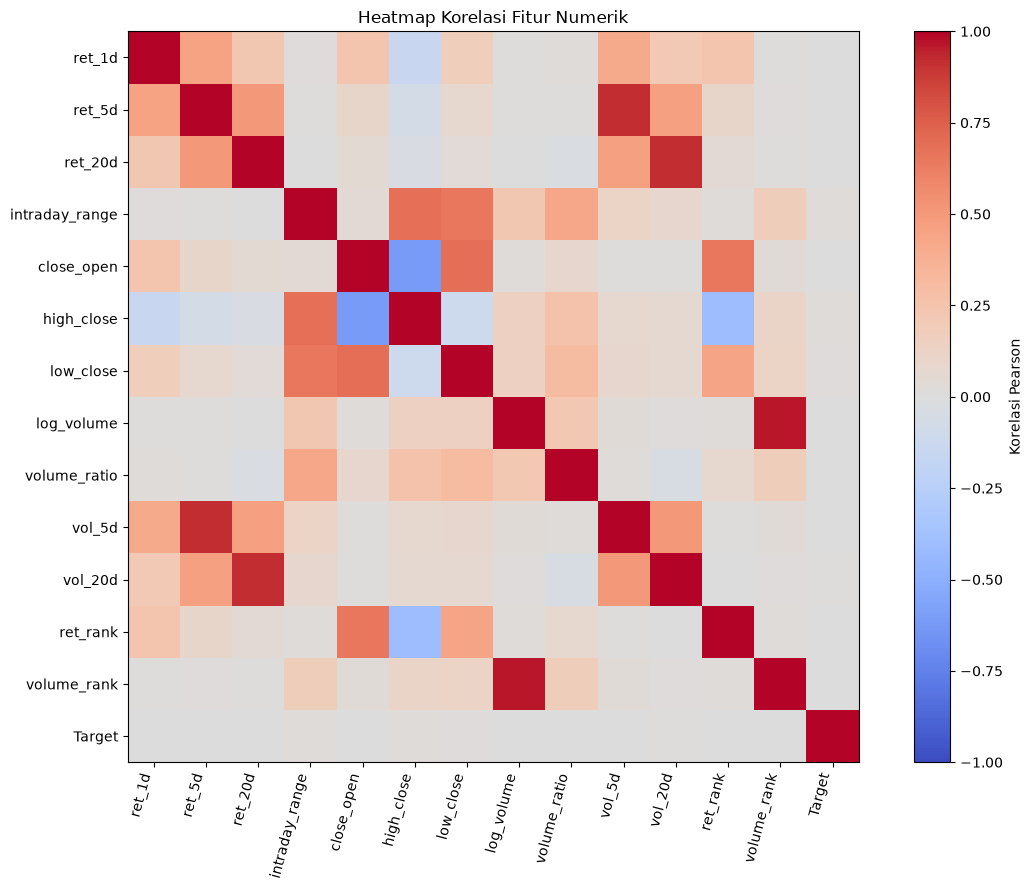

In [127]:
import matplotlib.pyplot as plt

plot_sample = train_fe.sample(n=min(50_000, len(train_fe)), random_state=42)

# 1. Heatmap korelasi fitur numerik terhadap fitur lainnya.
heatmap_cols = [
    "ret_1d", "ret_5d", "ret_20d", "intraday_range", "close_open",
    "high_close", "low_close", "log_volume", "volume_ratio",
    "vol_5d", "vol_20d", "ret_rank", "volume_rank", "Target",
]
heatmap_cols = [col for col in heatmap_cols if col in train_fe.columns]
corr_matrix = train_fe[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
image = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_cols)), heatmap_cols, rotation=75, ha="right")
ax.set_yticks(range(len(heatmap_cols)), heatmap_cols)
ax.set_title("Heatmap Korelasi Fitur Numerik")
fig.colorbar(image, ax=ax, label="Korelasi Pearson")
fig.tight_layout()
plt.show()


### Box Plot Deteksi Outlier per Fitur

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7180\4958370.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(plot_sample[col].dropna(), showfliers=True, vert=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7180\4958370.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(plot_sample[col].dropna(), showfliers=True, vert=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7180\4958370.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(plot_sample[col].dropna(), showfliers=True, vert=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7180\4958370.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib

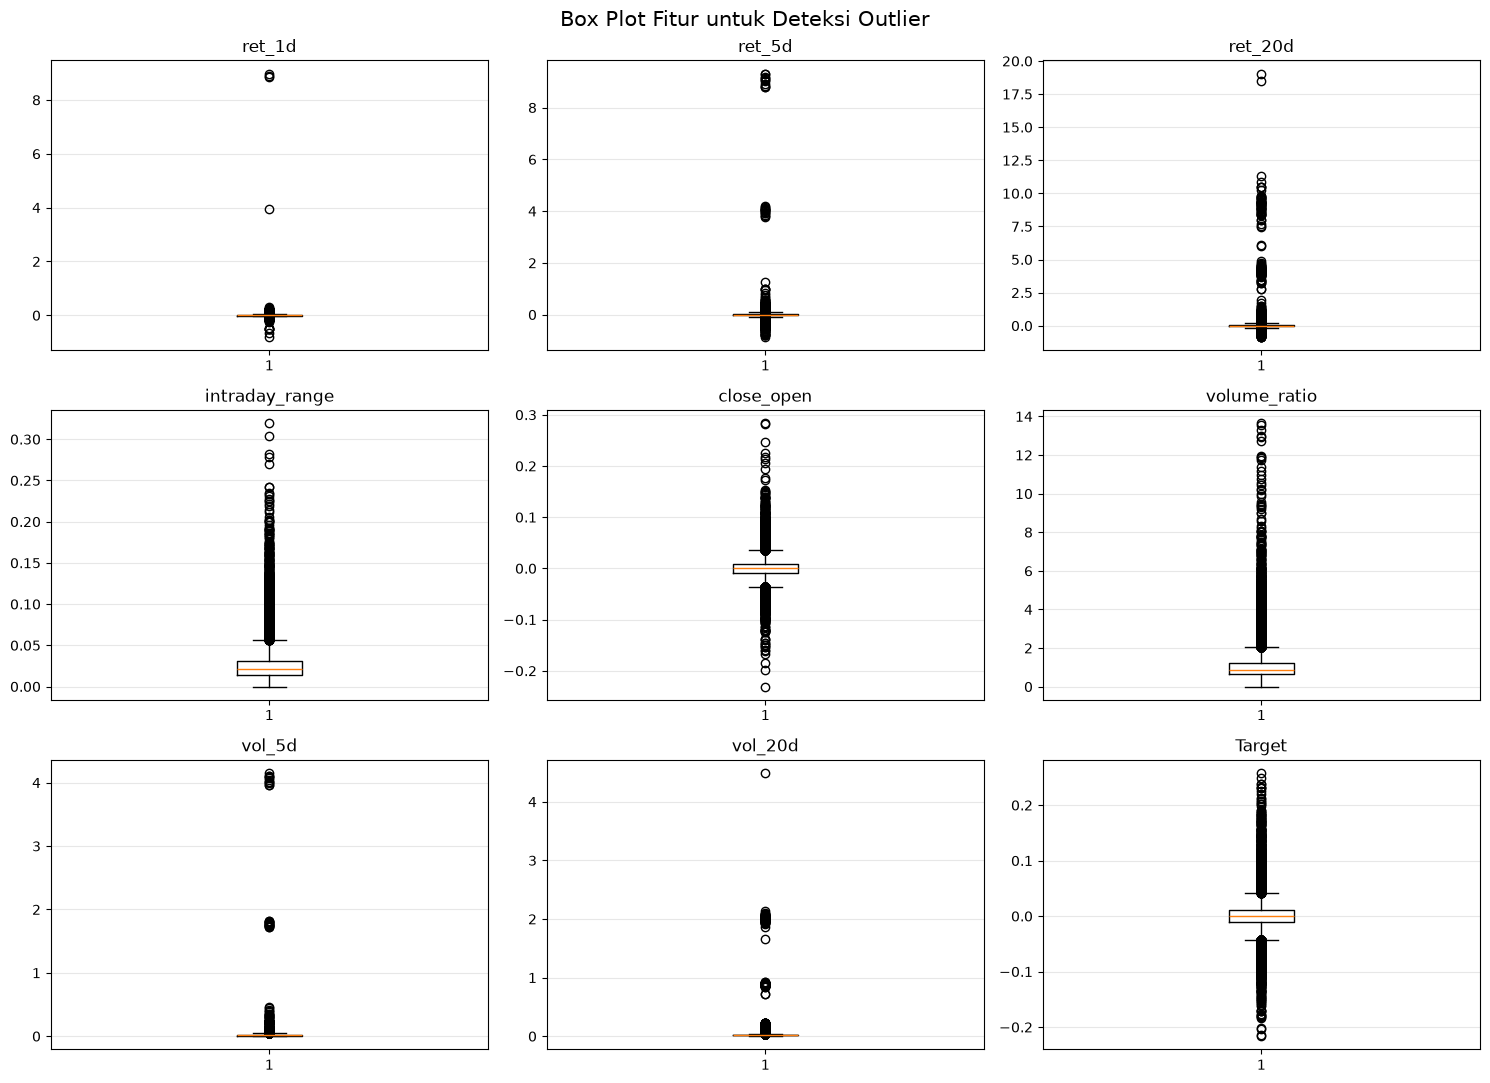

In [128]:
boxplot_cols = [
    "ret_1d", "ret_5d", "ret_20d", "intraday_range",
    "close_open", "volume_ratio", "vol_5d", "vol_20d", "Target",
]
boxplot_cols = [col for col in boxplot_cols if col in plot_sample.columns]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flat, boxplot_cols):
    ax.boxplot(plot_sample[col].dropna(), showfliers=True, vert=True)
    ax.set_title(col)
    ax.grid(axis="y", alpha=0.3)
for ax in axes.flat[len(boxplot_cols):]:
    ax.set_visible(False)
fig.suptitle("Box Plot Fitur untuk Deteksi Outlier", fontsize=15)
fig.tight_layout()
plt.show()

### Perbandingan ret_1d Sebelum vs Sesudah Capping

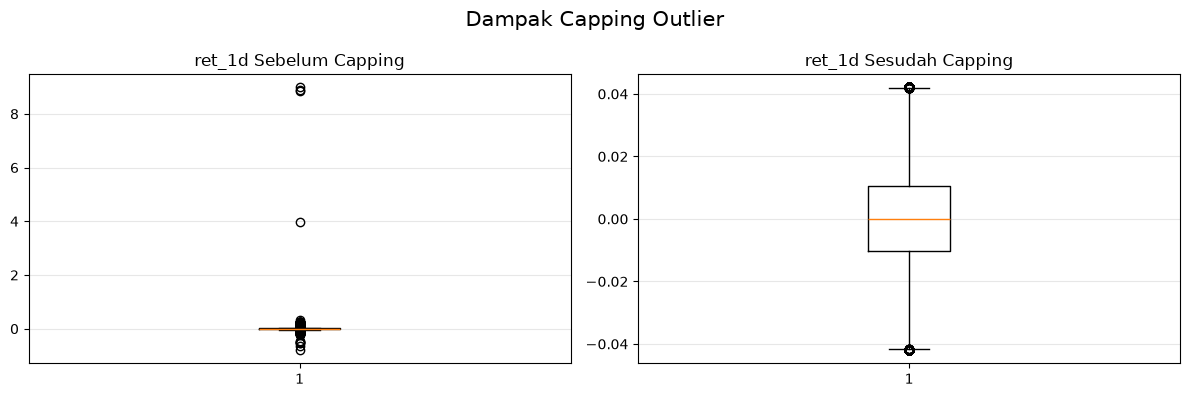

In [129]:
if "train_outlier" in globals() and "ret_1d" in train_outlier.columns:
    compare_sample = train_fe[["ret_1d"]].sample(n=min(50_000, len(train_fe)), random_state=42)
    capped_sample = train_outlier.loc[compare_sample.index, "ret_1d"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].boxplot(compare_sample["ret_1d"].dropna(), showfliers=True)
    axes[0].set_title("ret_1d Sebelum Capping")
    axes[1].boxplot(capped_sample.dropna(), showfliers=True)
    axes[1].set_title("ret_1d Sesudah Capping")
    for ax in axes:
        ax.grid(axis="y", alpha=0.3)
    fig.suptitle("Dampak Capping Outlier", fontsize=15)
    fig.tight_layout()
    plt.show()

# 7. Fitur Final

## 7.1 Rebuild dari frame clean

In [130]:
train = train_clean.copy()
test  = test_clean.copy()

train = train.drop(columns=["_year"], errors="ignore")
test  = test.drop(columns=["_year"], errors="ignore")

train = train.sort_values(["Date", "SecuritiesCode"]).reset_index(drop=True)
test  = test.sort_values(["Date", "SecuritiesCode"]).reset_index(drop=True)

print(f"Base frame : train={train.shape}  test={test.shape}")
print(f"Kolom awal : {list(train.columns)}")

Base frame : train=(1860029, 10)  test=(464894, 10)
Kolom awal : ['Unnamed: 0', 'RowId', 'Date', 'SecuritiesCode', 'Open', 'High', 'Low', 'Close', 'Volume', 'Target']


## 7.2 Fitur Temporal

In [131]:
for df_ in (train, test):
    df_["year"]       = df_["Date"].dt.year
    df_["month"]      = df_["Date"].dt.month
    df_["day"]        = df_["Date"].dt.day
    df_["dayofweek"]  = df_["Date"].dt.dayofweek
    df_["quarter"]    = df_["Date"].dt.quarter
    df_["dayofyear"]  = df_["Date"].dt.dayofyear
    df_["weekofyear"] = df_["Date"].dt.isocalendar().week.astype(int)

print("Fitur temporal ditambahkan:",
      ["year", "month", "day", "dayofweek", "quarter", "dayofyear", "weekofyear"])

Fitur temporal ditambahkan: ['year', 'month', 'day', 'dayofweek', 'quarter', 'dayofyear', 'weekofyear']


## 7.3 Encoding SecuritiesCode (Leak-free Target Encoding)

In [132]:
K = 50
global_mean = train["Target"].mean()

# Out-of-fold encoding untuk train (setiap baris di-encode tanpa melihat targetnya sendiri)
train["SecuritiesCode_te"] = np.nan
kf = KFold(n_splits=5, shuffle=False)  # tanpa shuffle -> tetap menghormati urutan waktu
for tr_idx, va_idx in kf.split(train):
    sub = train.iloc[tr_idx]
    agg = sub.groupby("SecuritiesCode")["Target"].agg(["mean", "count"])
    smoothed = (agg["count"] * agg["mean"] + K * global_mean) / (agg["count"] + K)
    train.loc[va_idx, "SecuritiesCode_te"] = (
        train.iloc[va_idx]["SecuritiesCode"].map(smoothed).values
    )
train["SecuritiesCode_te"] = train["SecuritiesCode_te"].fillna(global_mean).astype(np.float32)

# Full-train mapping untuk test (kode saham yang tak terlihat di train -> global mean)
agg_full = train.groupby("SecuritiesCode")["Target"].agg(["mean", "count"])
smoothed_full = (agg_full["count"] * agg_full["mean"] + K * global_mean) / (agg_full["count"] + K)
test["SecuritiesCode_te"] = (
    test["SecuritiesCode"].map(smoothed_full).fillna(global_mean).astype(np.float32)
)

print(f"SecuritiesCode_te dibuat. Sebaran (train): "
      f"mean={train['SecuritiesCode_te'].mean():.6f}, std={train['SecuritiesCode_te'].std():.6f}")

SecuritiesCode_te dibuat. Sebaran (train): mean=0.000373, std=0.000862


## 7.4 Fitur Return, Volatilitas, dan Cross-sectional Rank

In [133]:
train["_split"] = "train"
test["_split"]  = "test"
full = pd.concat([train, test], axis=0, ignore_index=True)
full = full.sort_values(["SecuritiesCode", "Date"]).reset_index(drop=True)
print(f"Concat: {full.shape}")

g = full.groupby("SecuritiesCode", sort=False)

# ---------- Returns (per-security, hanya pakai data historis) ----------
full["ret_1d"]  = g["Close"].pct_change()
full["ret_5d"]  = g["Close"].pct_change(5)
full["ret_20d"] = g["Close"].pct_change(20)

# ---------- Bentuk intraday (baris-per-baris, tidak bergantung waktu) ----------
full["intraday_range"] = (full["High"] - full["Low"]) / full["Close"]
full["close_open"]     = (full["Close"] - full["Open"]) / full["Open"]
full["high_close"]     = (full["High"] - full["Close"]) / full["Close"]
full["low_close"]      = (full["Close"] - full["Low"]) / full["Close"]

# ---------- Volume ----------
full["log_volume"]   = np.log1p(full["Volume"])
vol_ma20             = g["Volume"].transform(lambda s: s.rolling(20, min_periods=1).mean())
full["volume_ratio"] = full["Volume"] / vol_ma20
del vol_ma20

# ---------- Volatilitas ----------
full["vol_5d"]  = g["ret_1d"].transform(lambda s: s.rolling(5,  min_periods=2).std())
full["vol_20d"] = g["ret_1d"].transform(lambda s: s.rolling(20, min_periods=5).std())

# ---------- Rank cross-sectional (dalam Date yang sama) ----------
full["ret_rank"]    = full.groupby("Date")["ret_1d"].rank(pct=True)
full["volume_rank"] = full.groupby("Date")["Volume"].rank(pct=True)

print(f"Fitur return/volatilitas/rank ditambahkan. Shape full: {full.shape}")

Concat: (2324923, 19)
Fitur return/volatilitas/rank ditambahkan. Shape full: (2324923, 32)


## 7.5 Gabungkan & Finalisasi Feature Set

In [134]:
# Drop OHLCV mentah (sudah digantikan fitur turunan di atas)
full = full.drop(columns=["Open", "High", "Low", "Close", "Volume"])

# Pisah kembali ke train / test
train_final = full[full["_split"] == "train"].drop(columns="_split").reset_index(drop=True)
test_final  = full[full["_split"] == "test"].drop(columns="_split").reset_index(drop=True)

# Buang baris dengan NaN di awal riwayat tiap saham (akibat pct_change/rolling window)
print(f"Sebelum drop NaN: train={train_final.shape}  test={test_final.shape}")
train_final = train_final.dropna().reset_index(drop=True)
test_final  = test_final.dropna().reset_index(drop=True)
print(f"Setelah drop NaN: train={train_final.shape}  test={test_final.shape}")

# Buang identifier yang tidak lagi diperlukan sebagai fitur model
train_final = train_final.drop(columns=["RowId", "SecuritiesCode", "Date"])
test_final  = test_final.drop(columns=["RowId", "SecuritiesCode", "Date"])

print(f"\nFitur final ({len(train_final.columns)} kolom):")
print(list(train_final.columns))
print(f"\nNaN tersisa -> train: {int(train_final.isna().sum().sum())} | "
      f"test: {int(test_final.isna().sum().sum())}")
print(f"\ntrain_final shape: {train_final.shape}")
print(f"test_final  shape: {test_final.shape}")
train_final.head()

Sebelum drop NaN: train=(1860029, 26)  test=(464894, 26)
Setelah drop NaN: train=(1820193, 26)  test=(464730, 26)

Fitur final (23 kolom):
['Unnamed: 0', 'Target', 'year', 'month', 'day', 'dayofweek', 'quarter', 'dayofyear', 'weekofyear', 'SecuritiesCode_te', 'ret_1d', 'ret_5d', 'ret_20d', 'intraday_range', 'close_open', 'high_close', 'low_close', 'log_volume', 'volume_ratio', 'vol_5d', 'vol_20d', 'ret_rank', 'volume_rank']

NaN tersisa -> train: 0 | test: 0

train_final shape: (1820193, 23)
test_final  shape: (464730, 23)


,Unnamed: 0,Target,year,month,day,dayofweek,quarter,dayofyear,weekofyear,SecuritiesCode_te,...,intraday_range,close_open,high_close,low_close,log_volume,volume_ratio,vol_5d,vol_20d,ret_rank,volume_rank
0,38699,0.001838,2017,2,2,3,1,33,5,-0.000191,...,0.004031,-0.002194,0.002565,0.001466,9.741027,0.945232,0.003804,0.004883,0.755245,0.178322
1,40414,0.002202,2017,2,3,4,1,34,5,-0.000191,...,0.004779,-0.000735,0.004779,0.000000,9.698982,0.910360,0.003971,0.004924,0.329925,0.186760
2,42279,0.002197,2017,2,6,0,1,37,6,-0.000191,...,0.006239,-0.002927,0.003670,0.002569,9.787010,1.000000,0.003841,0.004943,0.495961,0.196015
3,44143,0.000000,2017,2,7,1,1,38,6,-0.000191,...,0.004394,0.002202,0.001831,0.002563,9.830971,1.061644,0.003336,0.004921,0.756611,0.201295
4,46159,0.002923,2017,2,8,2,1,39,6,-0.000191,...,0.004384,0.004035,0.000000,0.004384,9.711176,0.922819,0.002675,0.004948,0.430877,0.186391


# 8. Feature Scaling

## 8.1 Pisahkan Fitur dan Target

In [135]:
FEATURE_COLS = [c for c in train_final.columns if c != "Target"]
TARGET_COL = "Target"

X_train = train_final[FEATURE_COLS].values.astype(np.float64)
y_train = train_final[TARGET_COL].values.astype(np.float64).reshape(-1, 1)

X_test = test_final[FEATURE_COLS].values.astype(np.float64)
y_test = test_final[TARGET_COL].values.astype(np.float64).reshape(-1, 1)

print(f"Jumlah fitur: {len(FEATURE_COLS)}")
print(f"Fitur       : {FEATURE_COLS}")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test : {X_test.shape} | y_test : {y_test.shape}")

Jumlah fitur: 22
Fitur       : ['Unnamed: 0', 'year', 'month', 'day', 'dayofweek', 'quarter', 'dayofyear', 'weekofyear', 'SecuritiesCode_te', 'ret_1d', 'ret_5d', 'ret_20d', 'intraday_range', 'close_open', 'high_close', 'low_close', 'log_volume', 'volume_ratio', 'vol_5d', 'vol_20d', 'ret_rank', 'volume_rank']
X_train: (1820193, 22) | y_train: (1820193, 1)
X_test : (464730, 22) | y_test : (464730, 1)


## 8.2 Scaling untuk Pipeline SVR — StandardScaler 

In [136]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_X_svr = StandardScaler()
scaler_y_svr = StandardScaler()

# PENTING: fit HANYA pada data train, lalu transform ke train & test.
# Statistik (mean, std) scaler tidak pernah "melihat" data test -> tidak ada leakage.
X_train_svr = scaler_X_svr.fit_transform(X_train)
X_test_svr  = scaler_X_svr.transform(X_test)

y_train_svr = scaler_y_svr.fit_transform(y_train).ravel()
y_test_svr  = scaler_y_svr.transform(y_test).ravel()

print("Pipeline SVR (StandardScaler, fit di Train saja):")
print(f"X_train_svr: {X_train_svr.shape} | X_test_svr: {X_test_svr.shape}")

Pipeline SVR (StandardScaler, fit di Train saja):
X_train_svr: (1820193, 22) | X_test_svr: (464730, 22)


## 8.3 Scaling untuk Pipeline LSTM — MinMaxScaler 

In [137]:
scaler_X_lstm = MinMaxScaler()
scaler_y_lstm = MinMaxScaler()

X_train_lstm = scaler_X_lstm.fit_transform(X_train)
X_test_lstm  = scaler_X_lstm.transform(X_test)

y_train_lstm = scaler_y_lstm.fit_transform(y_train).ravel()
y_test_lstm  = scaler_y_lstm.transform(y_test).ravel()

print("Pipeline LSTM (MinMaxScaler, fit di Train saja):")
print(f"X_train_lstm: {X_train_lstm.shape} | X_test_lstm: {X_test_lstm.shape}")

Pipeline LSTM (MinMaxScaler, fit di Train saja):
X_train_lstm: (1820193, 22) | X_test_lstm: (464730, 22)
